##Trabalho Prático 2 - Machine Learning - Boosting
Raphaela Maria Costa e Silva - 2020006973

##Introdução
O Boosting é uma técnica de aprendizado de máquina amplamente utilizada que combina múltiplos classificadores fracos para formar um classificador forte e robusto. A ideia central do Boosting é treinar sequencialmente um conjunto de modelos simples, conhecidos como stumps de decisão, onde cada modelo tenta corrigir os erros cometidos pelo modelo anterior. Esta abordagem permite que o Boosting melhore significativamente a precisão de modelos simples, tornando-os comparáveis a modelos mais complexos.

Neste trabalho, implementamos o processo de Boosting utilizando stumps de decisão para resolver um problema de classificação binária com atributos categóricos. O dataset escolhido para os experimentos é o "Tic-Tac-Toe Endgame", disponível no repositório de aprendizado de máquina da UCI.

Os principais componentes deste trabalho incluem a implementação de um stump de decisão, que serve como nosso classificador fraco, e o desenvolvimento de um processo de Boosting que combina vários desses stumps para melhorar a performance de classificação.

##Imports



In [ ]:
!pip install ucimlrepo -q

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.base import BaseEstimator, ClassifierMixin
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt

##Importar o banco de dados
Prepara os dados do jogo da velha (Tic-Tac-Toe)

In [ ]:
# Fetch dataset
tic_tac_toe_endgame = fetch_ucirepo(id=101)

# Data (as pandas dataframes)
X = tic_tac_toe_endgame.data.features
y = tic_tac_toe_endgame.data.targets.iloc[:, 0]  # Garantir que y seja uma Série

# Mapear valores categóricos para numéricos
X = X.apply(lambda x: x.map({'x': 1, 'o': -1, 'b': 0}))
y = y.map({'positive': 1, 'negative': -1})




##Visualizar os dados

O dataset Tic-Tac-Toe Endgame contém informações sobre o estado do tabuleiro de jogo da velha, onde cada célula do tabuleiro pode conter um 'x', 'o' ou estar em branco ('b'). O objetivo é prever o resultado do jogo com base no estado do tabuleiro.

In [ ]:
X.head()

,top-left-square,top-middle-square,top-right-square,middle-left-square,middle-middle-square,middle-right-square,bottom-left-square,bottom-middle-square,bottom-right-square
0,1,1,1,1,-1,-1,1,-1,-1
1,1,1,1,1,-1,-1,-1,1,-1
2,1,1,1,1,-1,-1,-1,-1,1
3,1,1,1,1,-1,-1,-1,0,0
4,1,1,1,1,-1,-1,0,-1,0


In [ ]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: class, dtype: int64

##Bosting




O código é dividido em duas classes principais: DecisionStump e SimpleBoosting. A classe DecisionStump define a estrutura e o comportamento de um stump de decisão, enquanto a classe SimpleBoosting define o processo de Boosting usando esses stumps.

Implementação de DecisionStump
A classe DecisionStump é responsável por criar um classificador fraco que toma decisões baseadas em um único atributo. Dentro dessa classe, o método fit encontra o melhor atributo (coluna) e o melhor limiar para dividir os dados, minimizando o erro de classificação. A escolha do atributo e do limiar é feita iterando sobre todos os atributos e possíveis limiares, calculando o erro ponderado para cada combinação. Se o erro for maior que 0.5, a polaridade da predição é invertida, e o erro é ajustado para ser menor que 0.5. O método predict usa o atributo e o limiar escolhidos para fazer previsões sobre novos dados, ajustando as predições com base na polaridade determinada durante o treinamento.

Implementação de SimpleBoosting
A classe SimpleBoosting implementa o processo de Boosting, combinando vários stumps de decisão para criar um classificador mais forte. O construtor da classe inicializa os parâmetros do Boosting, como o número de estimadores (n_estimators) e listas para armazenar os pesos (alphas) e modelos (models) dos stumps. O método fit treina os stumps iterativamente. Para cada iterador, ele ajusta um DecisionStump aos dados ponderados, calcula o erro do stump, e então ajusta os pesos das amostras com base na performance do stump. A importância de cada stump é calculada como alpha, que depende do erro do stump, e é usada para atualizar os pesos das amostras de forma exponencial. O método predict faz previsões combinando as predições de todos os stumps treinados, ponderadas por seus respectivos alphas, e retornando a classe final como a soma ponderada das predições.

In [ ]:

# Implementação de um stump de decisão para o Boosting
class DecisionStump:
    def __init__(self):
        self.feature_index = None
        self.threshold = None
        self.polarity = 1

    def fit(self, X, y, sample_weight=None):
        n_samples, n_features = X.shape
        min_error = float('inf')

        for feature_i in range(n_features):
            X_column = X.iloc[:, feature_i]
            thresholds = np.unique(X_column)

            for threshold in thresholds:
                p = 1
                predictions = np.ones(n_samples)
                predictions[X_column < threshold] = -1
                error = np.sum(sample_weight[y != predictions])

                if error > 0.5:
                    error = 1 - error
                    p = -1

                if error < min_error:
                    self.polarity = p
                    self.threshold = threshold
                    self.feature_index = feature_i
                    min_error = error

        return min_error

    def predict(self, X):
        n_samples = X.shape[0]
        X_column = X.iloc[:, self.feature_index]
        predictions = np.ones(n_samples)
        if self.polarity == 1:
            predictions[X_column < self.threshold] = -1
        else:
            predictions[X_column >= self.threshold] = -1
        return predictions

# Implementação do Boosting simples
class SimpleBoosting:
    def __init__(self, n_estimators):
        self.n_estimators = n_estimators
        self.alphas = []
        self.models = []

    def fit(self, X, y):
        n_samples = len(X)
        w = np.ones(n_samples) / n_samples  # Inicializar pesos

        for _ in range(self.n_estimators):
            stump = DecisionStump()
            error = stump.fit(X, y, w)
            alpha = 0.5 * np.log((1 - error) / (error + 1e-10))

            predictions = stump.predict(X)
            w *= np.exp(-alpha * y * predictions)
            w /= np.sum(w)

            self.models.append(stump)
            self.alphas.append(alpha)

    def predict(self, X):
        stump_preds = np.array([stump.predict(X) for stump in self.models])
        return np.sign(np.dot(self.alphas, stump_preds))


##Validação Cruzada
Trainamento usando validação cruzada com 5 partições

In [ ]:
# Função para calcular erro médio usando validação cruzada
def cross_val_error(models, alphas, X, y, cv=5):
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    test_errors = []

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        test_predictions = np.zeros(len(X_test))

        for model, alpha in zip(models, alphas):
            test_predictions += alpha * model.predict(X_test)

        test_error = np.mean(y_test != np.sign(test_predictions))

        test_errors.append(test_error)

    return np.mean(test_errors)


In [ ]:
# Definição do número máximo de stumps
max_estimators = 300

# Treinamento inicial para obter os modelos e alphas para todos os stumps até max_estimators
boosting_model = SimpleBoosting(max_estimators)
boosting_model.fit(X, y)

# Armazenamento dos modelos e alphas
models = boosting_model.models
alphas = boosting_model.alphas

# Avaliação dos erros de treino e teste para todos os números de stumps até max_estimators
stump_range = range(1, max_estimators + 1)
mean_test_errors = []

for n_estimators in stump_range:
    mean_error_test = cross_val_error(models[:n_estimators], alphas[:n_estimators], X, y, cv=5)
    mean_test_errors.append(mean_error_test)



##Resultados

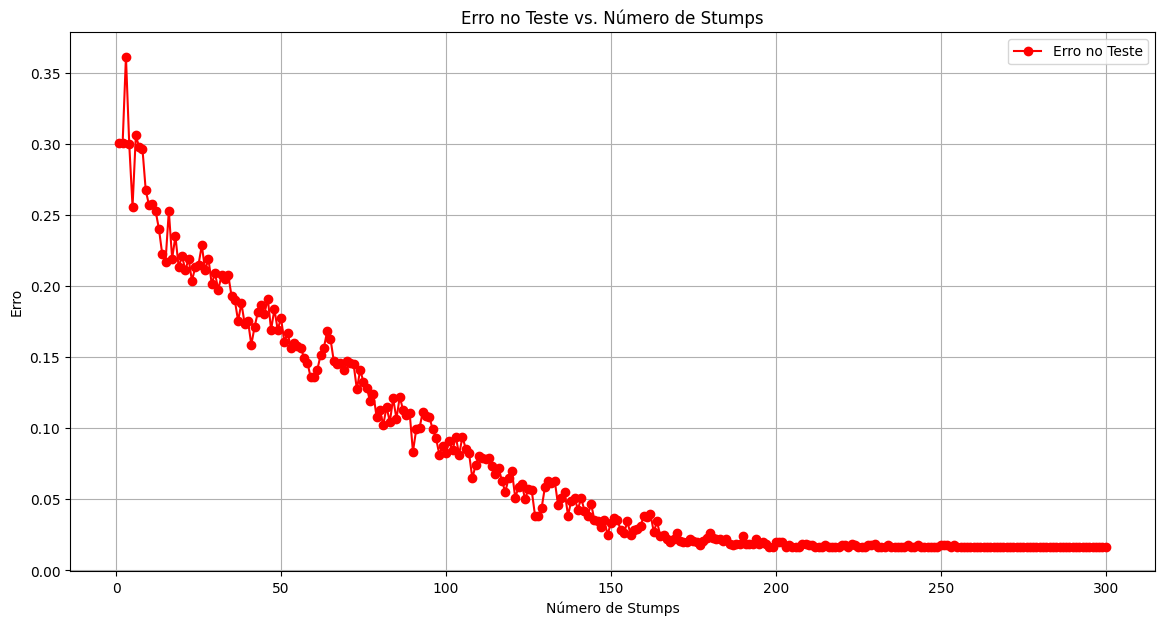

In [ ]:
# Plotando os resultados
plt.figure(figsize=(14, 7))
# Plotando o erro no teste
plt.plot(stump_range, mean_test_errors, marker='o', color='r', label='Erro no Teste')

plt.title('Erro no Teste vs. Número de Stumps')
plt.xlabel('Número de Stumps')
plt.ylabel('Erro')
plt.legend()
plt.grid(True)
plt.show()

Os resultados do experimento demonstram que a acurácia do modelo estabiliza após aproximadamente 200 stumps, deixando de aumentar significativamente. O modelo aparenta ser robusto, com uma acurácia muito boa.








##Conclusão
Ao concluir este trabalho, podemos destacar que a implementação do algoritmo Boost para resolver o problema de classificação binária no jogo da velha foi bem-sucedida. Utilizando 300 decision stumps como classificadores fracos, alcançamos uma acurácia robusta. Isso demonstra a eficácia do Boost em melhorar a precisão preditiva ao combinar múltiplos modelos fracos. Além disso, a documentação detalhada das funções e a análise dos resultados obtidos reforçam a confiabilidade e a compreensão do processo implementado. Este trabalho não apenas validou a aplicação do Boost para o problema específico do jogo da velha, mas também ressaltou sua capacidade de proporcionar resultados consistentes e confiáveis em cenários de classificação desafiadores.






